# Map back airway sputum annotations to the combined object

Imports

In [3]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'refined-clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'

NEW_COMB_V = 'refined-clustered'
NEW_COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{NEW_COMB_V}.h5ad'

SUB_OBJ = "T"
SUB_OBJ_V = 'reclustered'
SUB_OBJ_PATH = MAIN_DIR / 'data' / 'sub' / SUB_OBJ / 'h5ad' / f'{SUB_OBJ}-{SUB_OBJ_V}.h5ad'

In [ ]:
# load comb obj
comb = sc.read_h5ad(COMB_PATH)

In [ ]:
# load airway epi obj
sub = sc.read_h5ad(SUB_OBJ_PATH)

Get all the cell names and annotations

In [ ]:
sub_ann = sub.obs[["leiden","reclustered_ct"]].copy()

In [43]:

sub_ann = sub_ann.rename(columns={
    "leiden": f"{SUB_OBJ}_leiden_n10_0.3",
    "reclustered_ct": "ann_lvl_3_refined",
})

sub_ann

,plasma_leiden_n10_0.3,ann_lvl_3_refined
cell_id,,
SLIDE04_11,0,EC
SLIDE04_12,2,EC
SLIDE04_26,1,EC
SLIDE04_66,1,EC
SLIDE04_67,1,EC
...,...,...
SLIDE02_426977,3,lymEC
SLIDE02_426979,1,EC
SLIDE02_426982,2,EC


Map back

In [44]:
# Add the airway Leiden clusters; non-airway cells will be NaN
comb.obs[f"{SUB_OBJ}_leiden_n10_0.3"] = (
    sub_ann[f"{SUB_OBJ}_leiden_n10_0.3"]
    .reindex(comb.obs.index)
)

# Start with the original annotation for every cell
comb.obs["ann_lvl_3_refined"] = comb.obs["ann_lvl_3_refined"].astype(str)

# Replace annotations only for cells present in sub_ann
common_cells = comb.obs.index.intersection(sub_ann.index)

comb.obs.loc[common_cells, "ann_lvl_3_refined"] = (
    sub_ann.loc[common_cells, "ann_lvl_3_refined"].astype(str)
)

... storing 'ann_lvl_3_refined' as categorical


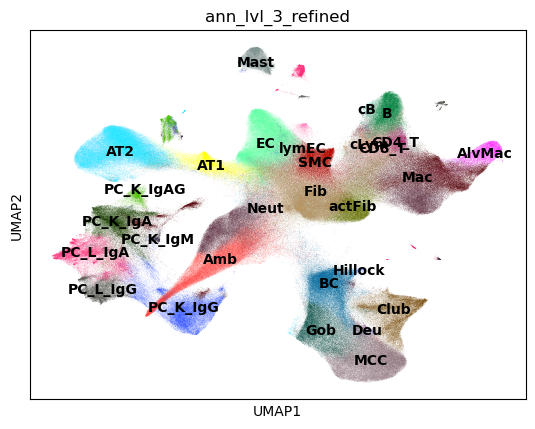

In [45]:
sc.pl.umap(
    comb, 
    color=["ann_lvl_3_refined"],
    #groups=['Amb'],
    legend_loc="on data"
)

In [46]:
# how many cell types until now
comb.obs['ann_lvl_3_refined'].unique()

['PC_K_IgA', 'Fib', 'Neut', 'CD8_T', 'SMC', ..., 'Gob', 'MCC', 'cB', 'Hillock', 'Deu']
Length: 29
Categories (29, object): ['AT1', 'AT2', 'AlvMac', 'Amb', ..., 'actFib', 'cB', 'cLym', 'lymEC']

Save the annotated object

In [47]:
comb.write_h5ad(NEW_COMB_PATH)